In [16]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

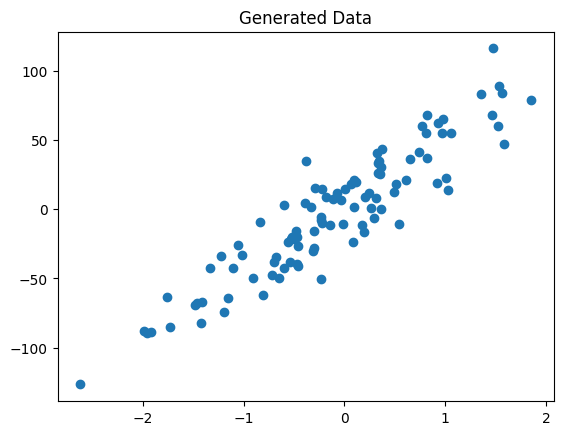

In [17]:
X, y = make_regression(
    n_samples=100,
    n_features=1,
    noise=20,
    random_state=42
)

plt.scatter(X, y)
plt.title("Generated Data")
plt.show()

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("\n--- Sklearn Model ---")
print("Coefficient:", lr.coef_)
print("Intercept:", lr.intercept_)
print("R2 Score:", r2_score(y_test, y_pred))


--- Sklearn Model ---
Coefficient: [46.747264]
Intercept: 0.19844442845175525
R2 Score: 0.8019015156159199


In [6]:
from sklearn.metrics import r2_score
y_pred = lr.predict(X_test)
print("R^2 Score:", r2_score(y_test, y_pred))


R^2 Score: 0.8019015156159199


In [20]:
class GDRegressor:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.m = 0
        self.b = 0
        self.losses = []

    def fit(self, X, y):
        X = X.ravel()

        for _ in range(self.epochs):
            y_pred = self.m * X + self.b

            error = y - y_pred

            # gradients
            dm = -2 * np.mean(X * error)
            db = -2 * np.mean(error)

            # update
            self.m -= self.lr * dm
            self.b -= self.lr * db

            # track loss
            loss = np.mean(error ** 2)
            self.losses.append(loss)

    def predict(self, X):
        return self.m * X + self.b
          

In [21]:
gd = GDRegressor(learning_rate=0.01, epochs=1000)
gd.fit(X_train, y_train)

y_pred_gd = gd.predict(X_test)

print("\n--- From Scratch Model ---")
print("m:", gd.m)
print("b:", gd.b)
print("R2 Score:", r2_score(y_test, y_pred_gd))


--- From Scratch Model ---
m: 46.74725659779171
b: 0.19844040212706793
R2 Score: 0.8019014721445831


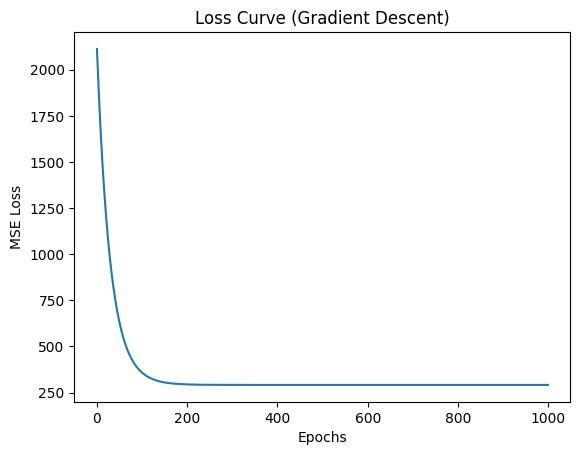

In [22]:
plt.plot(gd.losses)
plt.title("Loss Curve (Gradient Descent)")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()